In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, accuracy_score
from imblearn.over_sampling import SMOTE
import shap

# Set visualization theme
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Load the dataset
data = pd.read_csv('/Users/ashleshasanjaykadam/Downloads/data.csv')

# Drop unnecessary columns
data.drop(['id', 'Unnamed: 0'], axis=1, inplace=True)

# Convert numeric-like object columns to numeric
price_cols = [
    'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice',
    'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice',
    'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice',
    'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost'
]
for col in price_cols:
    data[col] = pd.to_numeric(data[col].replace({',': '', r'\$': ''}, regex=True), errors='coerce')

# Fill missing values
numeric_cols = data.select_dtypes(include=[np.number]).columns
categorical_cols = data.select_dtypes(include=['object']).columns

# Replace missing numeric values with the median (robust to outliers)
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# Replace missing categorical values with the mode (most common category)
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [3]:
# One-hot encode categorical variables to handle non-numeric data
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = pd.DataFrame(encoder.fit_transform(data[categorical_cols]), columns=encoder.get_feature_names_out(categorical_cols))

# Combine encoded categorical data with numeric features
data = pd.concat([data[numeric_cols], encoded_data], axis=1)

/var/folders/0c/rcbwzjhs28s93kv8t9tt6vl80000gn/T/ipykernel_2974/389405563.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette="pastel")


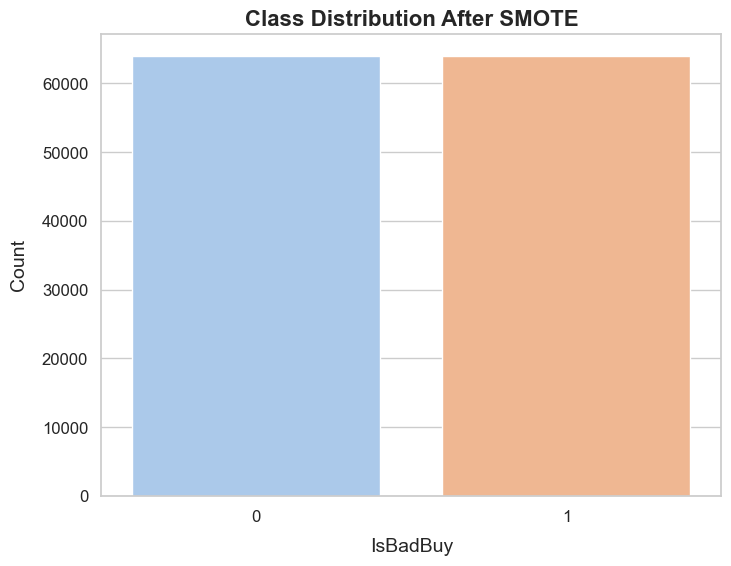

In [4]:
# Separate features (X) and target variable (y)
X = data.drop(columns=['IsBadBuy'])
y = data['IsBadBuy']

# Use SMOTE to handle class imbalance in the target variable
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Plot class distribution after applying SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled, palette="pastel")
plt.title("Class Distribution After SMOTE", fontsize=16, weight="bold")
plt.xlabel("IsBadBuy", fontsize=14, labelpad=10)
plt.ylabel("Count", fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [5]:
# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Scale features to ensure they are on the same scale for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Define a dictionary of models for comparison
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42)
}

--- Logistic Regression ---
Accuracy: 0.8394
ROC AUC: 0.8959
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.86     12933
           1       0.97      0.70      0.81     12670

    accuracy                           0.84     25603
   macro avg       0.87      0.84      0.84     25603
weighted avg       0.87      0.84      0.84     25603

Confusion Matrix:


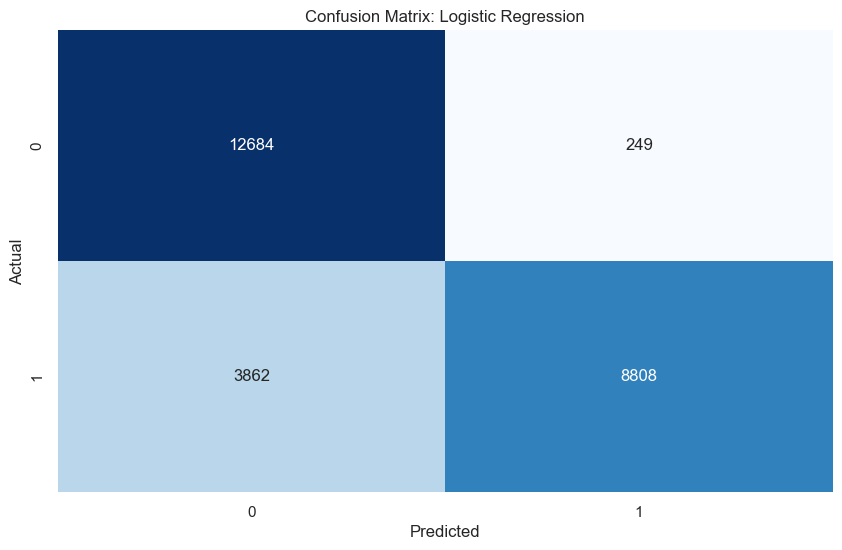

--- Random Forest ---
Accuracy: 0.9312
ROC AUC: 0.9634
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     12933
           1       0.99      0.87      0.93     12670

    accuracy                           0.93     25603
   macro avg       0.94      0.93      0.93     25603
weighted avg       0.94      0.93      0.93     25603

Confusion Matrix:


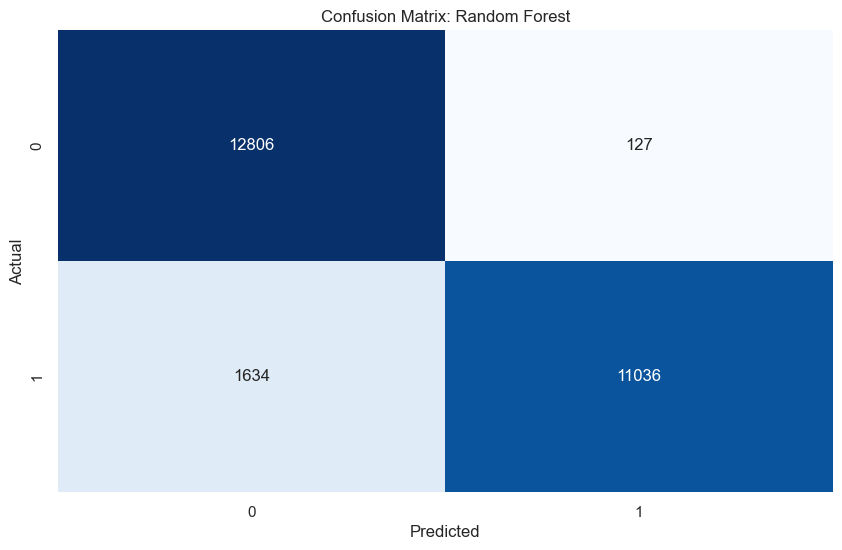

--- XGBoost ---


/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [22:38:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9216
ROC AUC: 0.9579
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93     12933
           1       0.99      0.85      0.91     12670

    accuracy                           0.92     25603
   macro avg       0.93      0.92      0.92     25603
weighted avg       0.93      0.92      0.92     25603

Confusion Matrix:


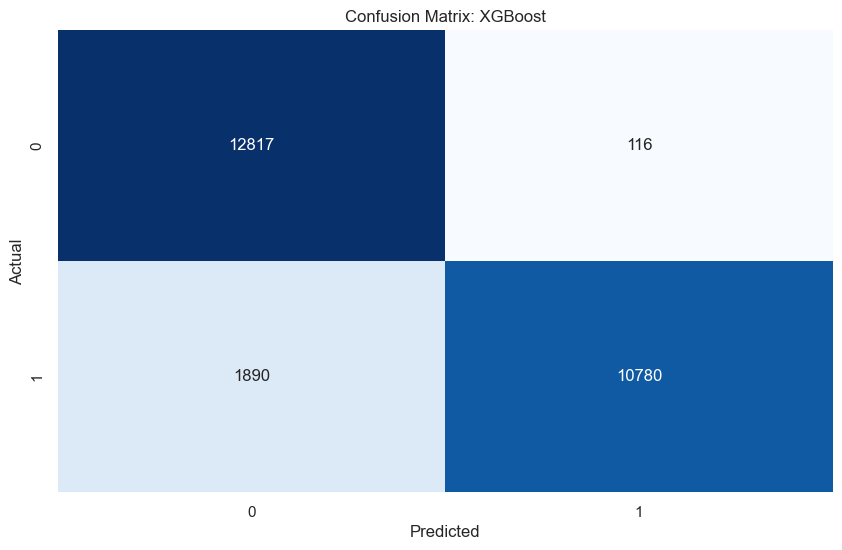

--- LightGBM ---
[LightGBM] [Info] Number of positive: 51337, number of negative: 51074
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071868 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20632
[LightGBM] [Info] Number of data points in the train set: 102411, number of used features: 111
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501284 -> initscore=0.005136
[LightGBM] [Info] Start training from score 0.005136
Accuracy: 0.9194
ROC AUC: 0.9559
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93     12933
           1       1.00      0.84      0.91     12670

    accuracy                           0.92     25603
   macro avg       0.93      0.92      0.92     25603
weighted avg       0.93      0.92      0.92     25603

Confusion Matrix:


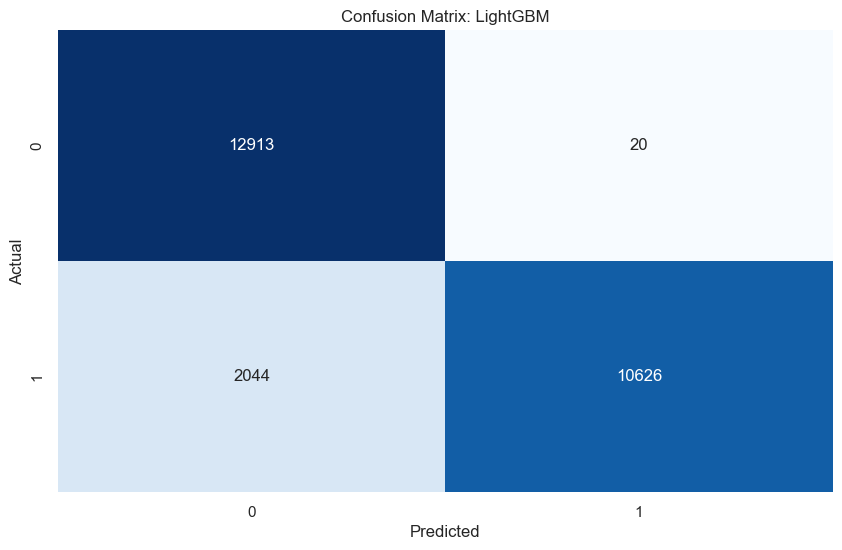

In [7]:
# Train and evaluate each model
for model_name, model in models.items():
    print(f"--- {model_name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Display model performance metrics
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

/var/folders/0c/rcbwzjhs28s93kv8t9tt6vl80000gn/T/ipykernel_2974/368523886.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


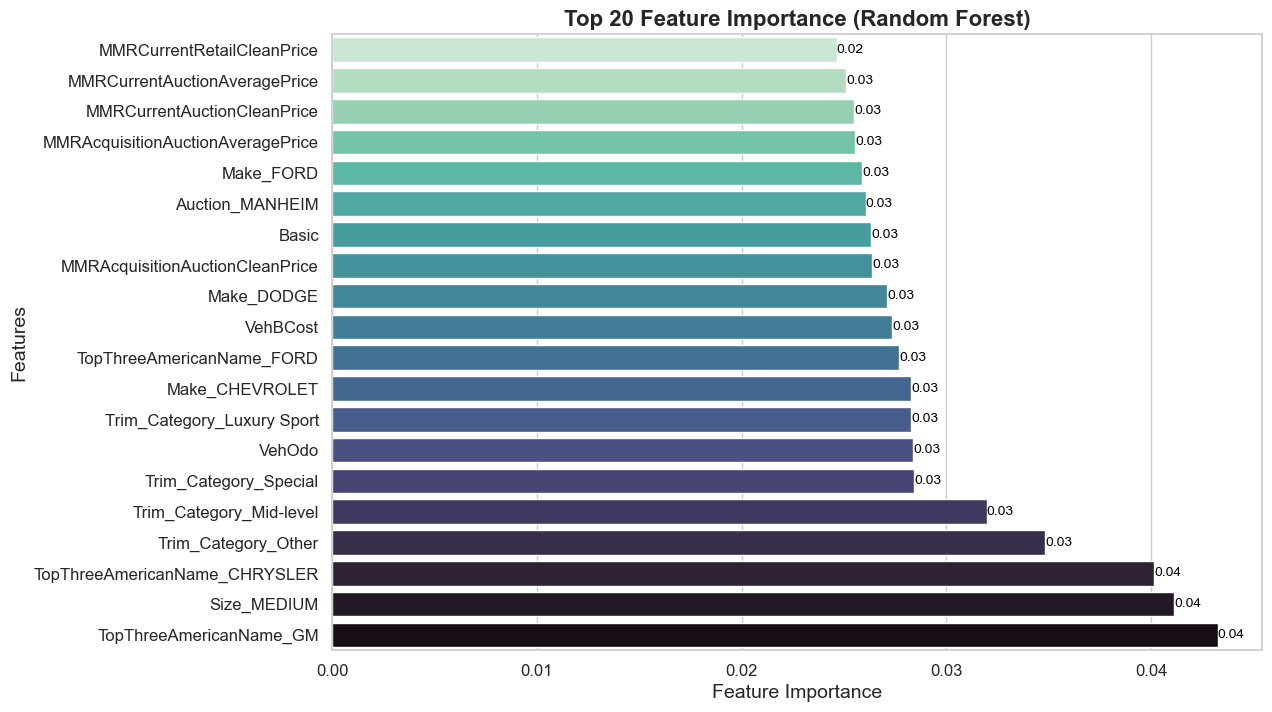

In [8]:
# Visualize feature importance for Random Forest

# Plot the top 20 most important features from Random Forest
importances = models['Random Forest'].feature_importances_
features = X.columns
sorted_idx = np.argsort(importances)[::-1][:20]  # Select top 20 features

plt.figure(figsize=(12, 8))
sns.barplot(
    x=importances[sorted_idx],
    y=features[sorted_idx],
    palette="mako"
)
plt.title("Top 20 Feature Importance (Random Forest)", fontsize=16, weight='bold')
plt.xlabel("Feature Importance", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().invert_yaxis()  # Ensure the most important feature is at the top

# Annotate the importance values
for i, v in enumerate(importances[sorted_idx]):
    plt.text(v, i, f"{v:.2f}", color='black', va='center', fontsize=10)

plt.show()

/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


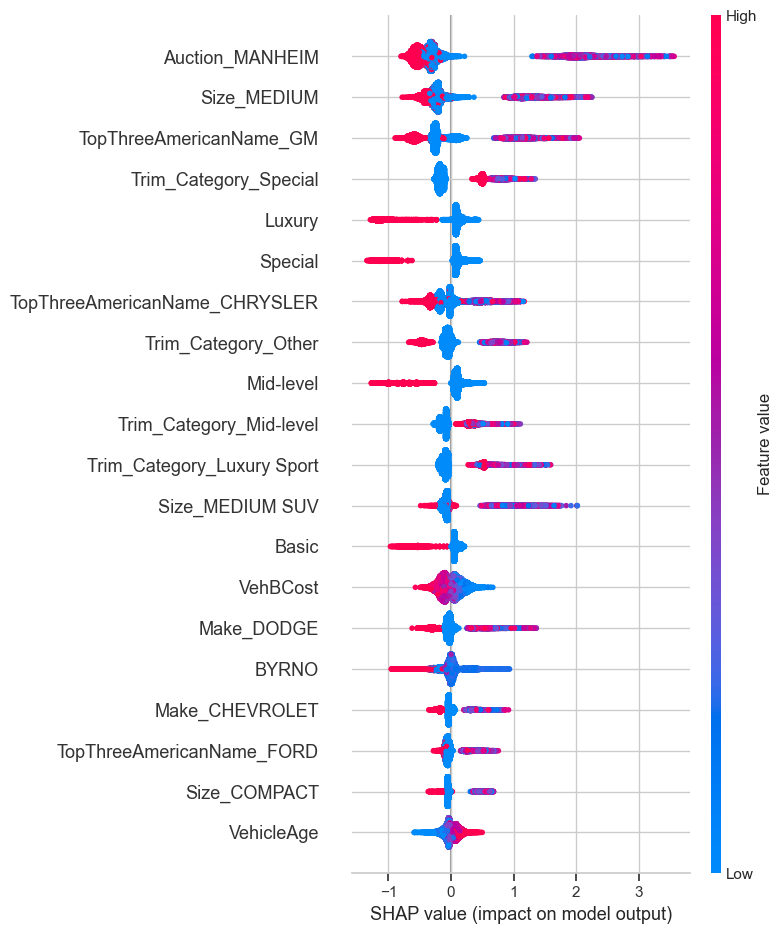

In [9]:
# Explain predictions using SHAP (for LightGBM)
explainer = shap.TreeExplainer(models['LightGBM'])
shap_values = explainer.shap_values(X_test_scaled)

# Visualize SHAP summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

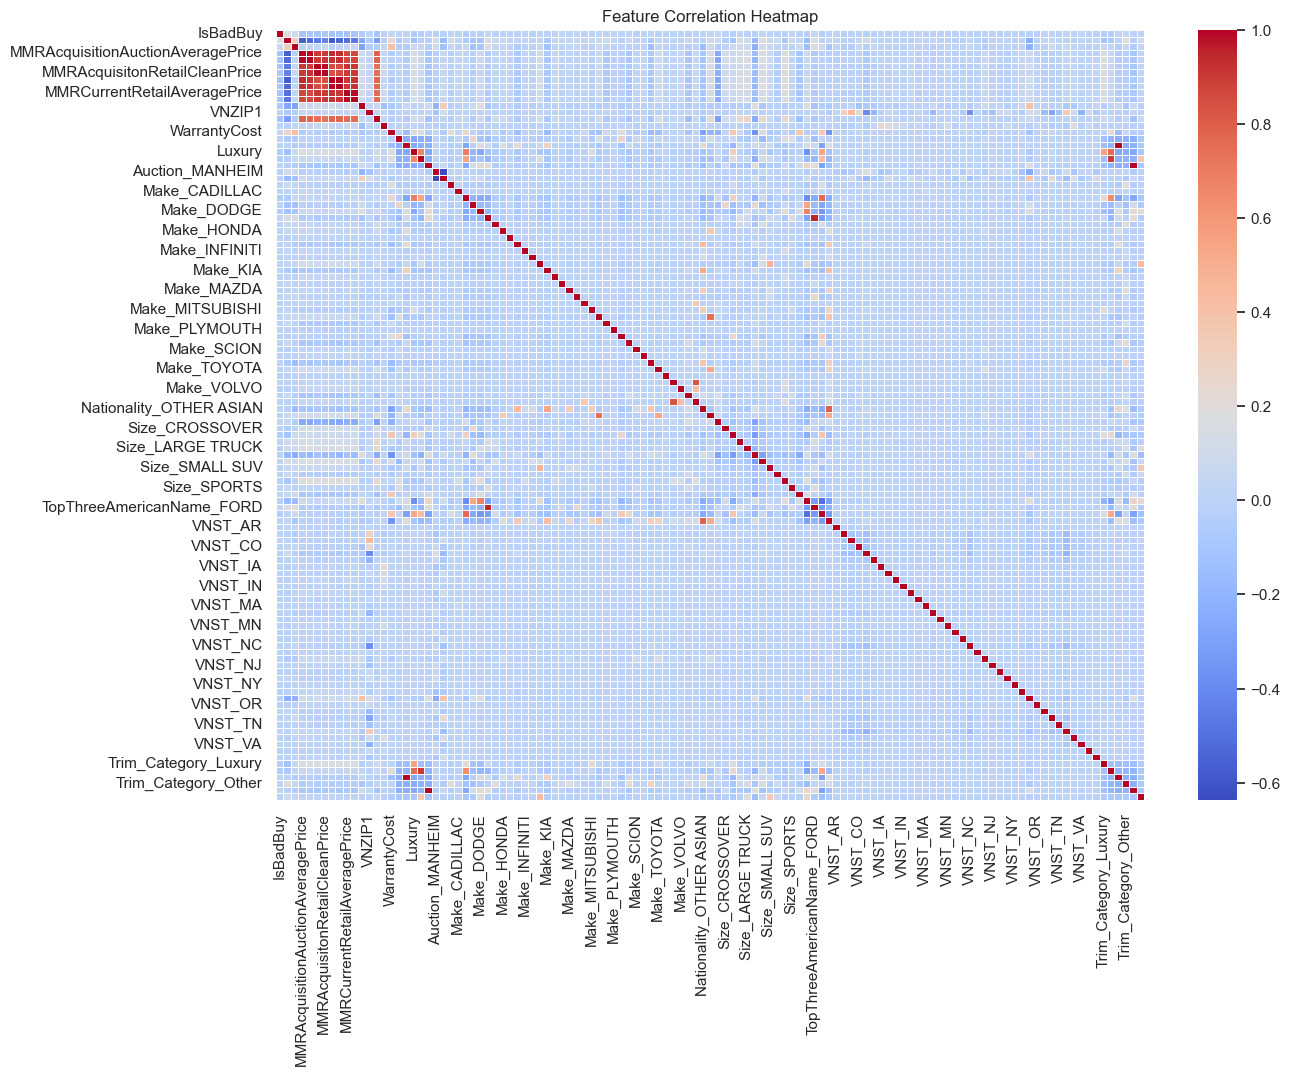

In [9]:
# Plot a heatmap to show correlations among numeric features
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

/var/folders/0c/rcbwzjhs28s93kv8t9tt6vl80000gn/T/ipykernel_2974/1169866624.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


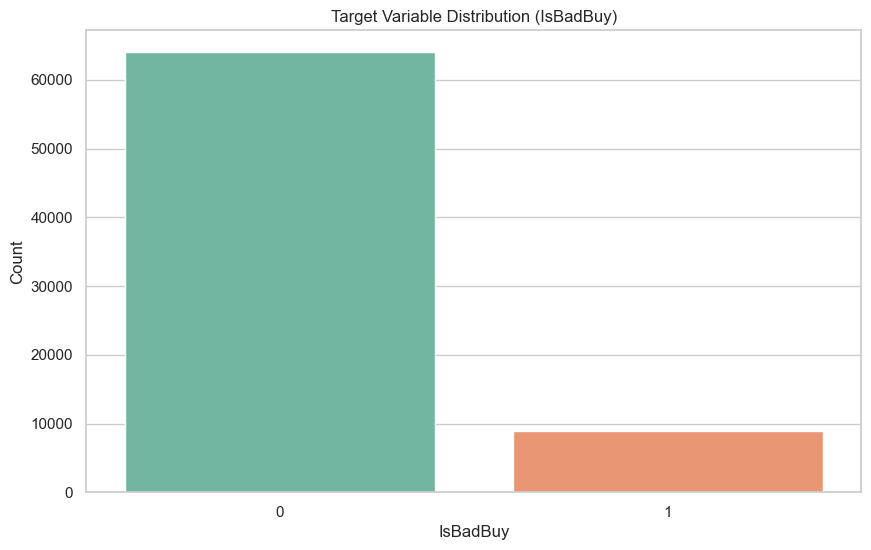

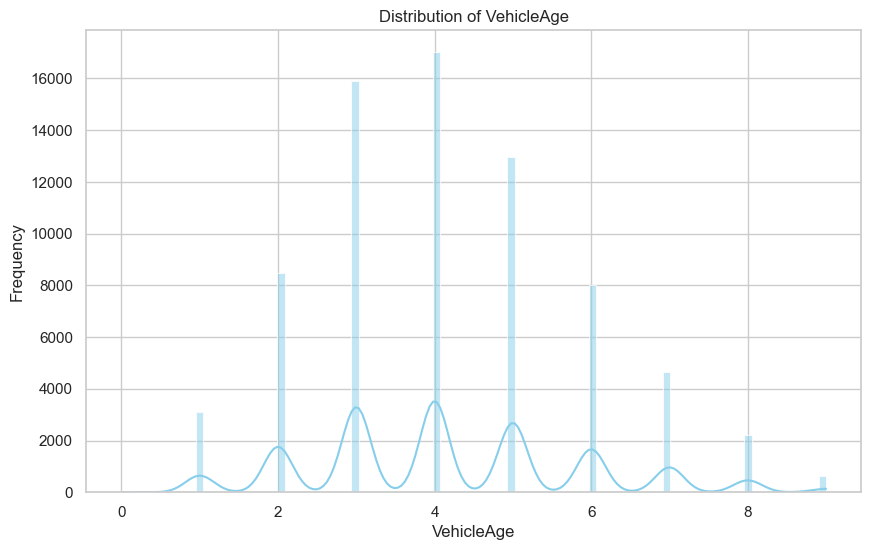

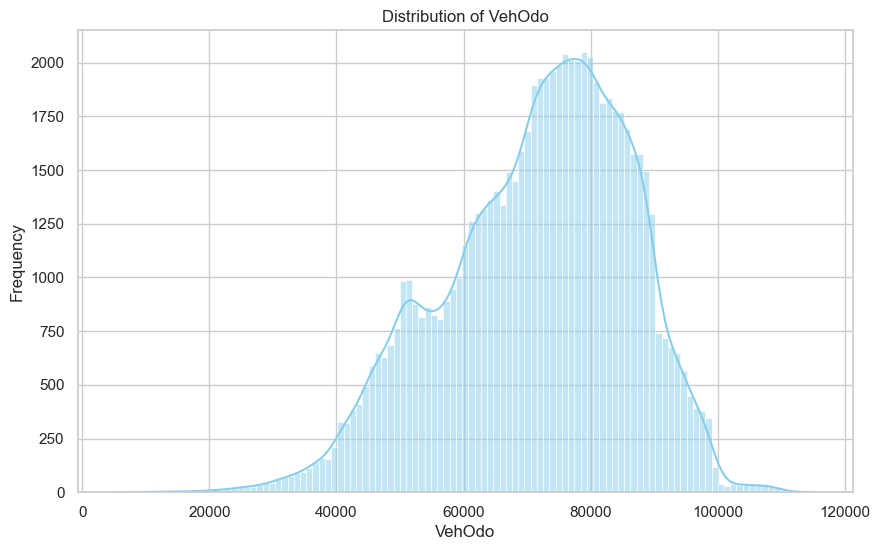

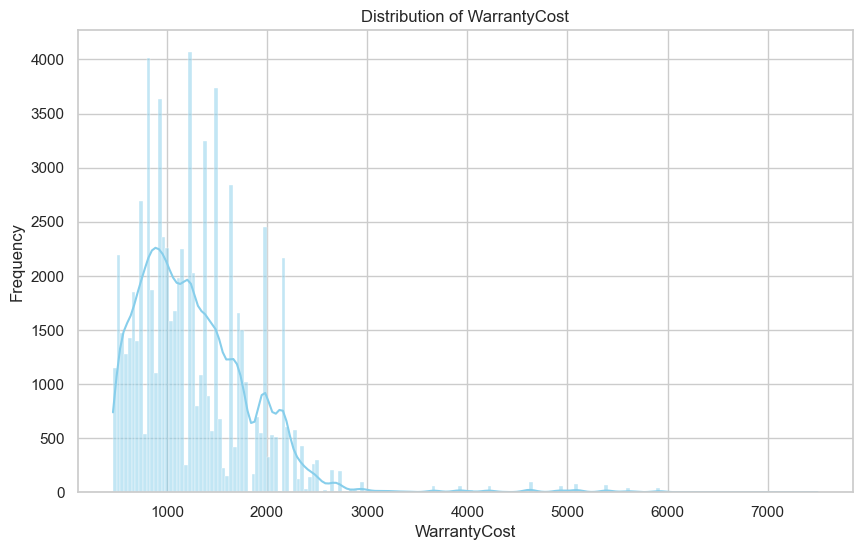

/var/folders/0c/rcbwzjhs28s93kv8t9tt6vl80000gn/T/ipykernel_2974/1169866624.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X['VehicleAge'], palette="Set3")


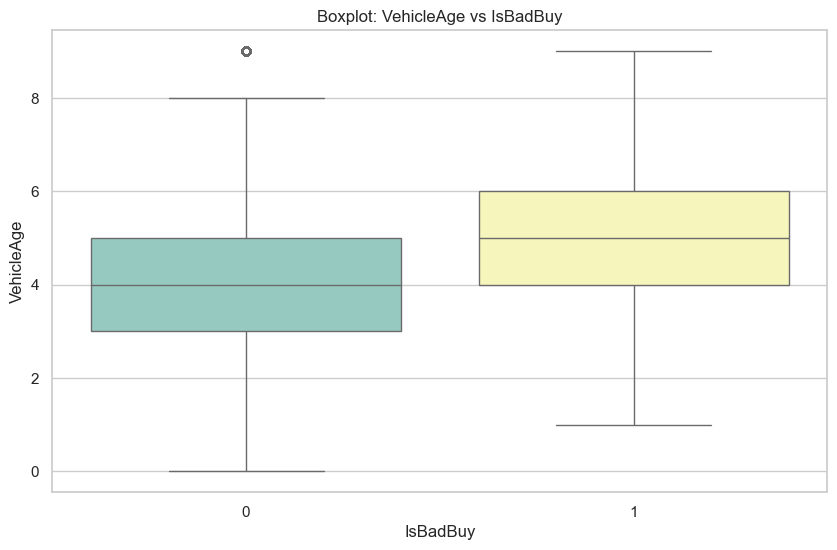

In [10]:
# Plot distribution of target variable (IsBadBuy)
sns.countplot(x=y, palette="Set2")
plt.title("Target Variable Distribution (IsBadBuy)")
plt.xlabel("IsBadBuy")
plt.ylabel("Count")
plt.show()

# Histogram of key features
important_features = ['VehicleAge', 'VehOdo', 'WarrantyCost']
for feature in important_features:
    sns.histplot(X[feature], kde=True, color="skyblue")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

# Boxplot to show relationship between VehicleAge and IsBadBuy
sns.boxplot(x=y, y=X['VehicleAge'], palette="Set3")
plt.title("Boxplot: VehicleAge vs IsBadBuy")
plt.xlabel("IsBadBuy")
plt.ylabel("VehicleAge")
plt.show()

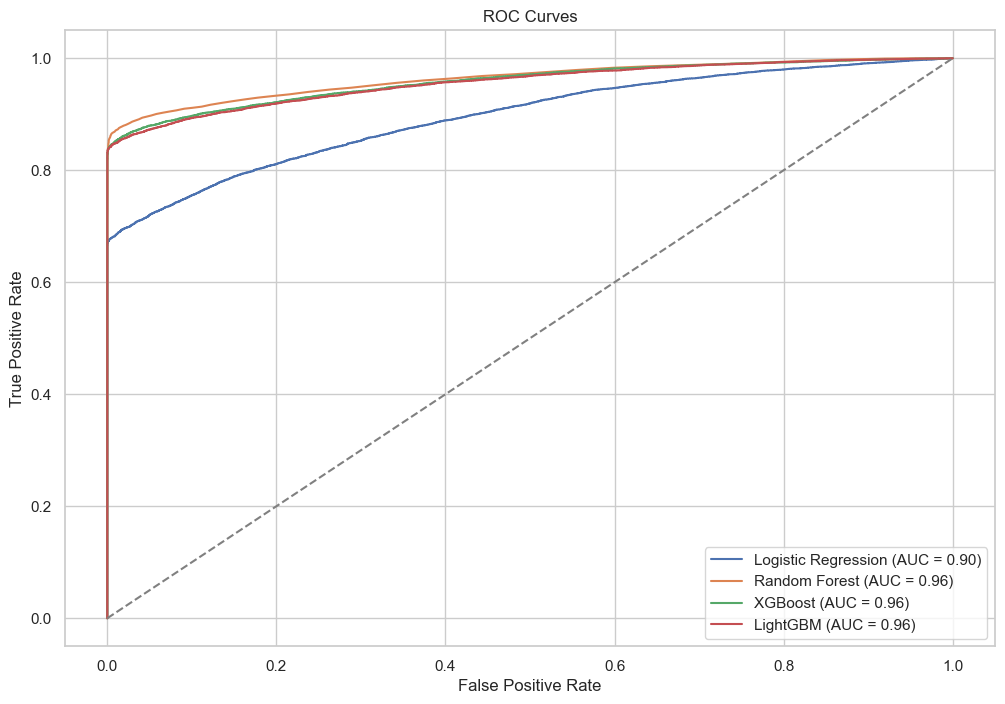

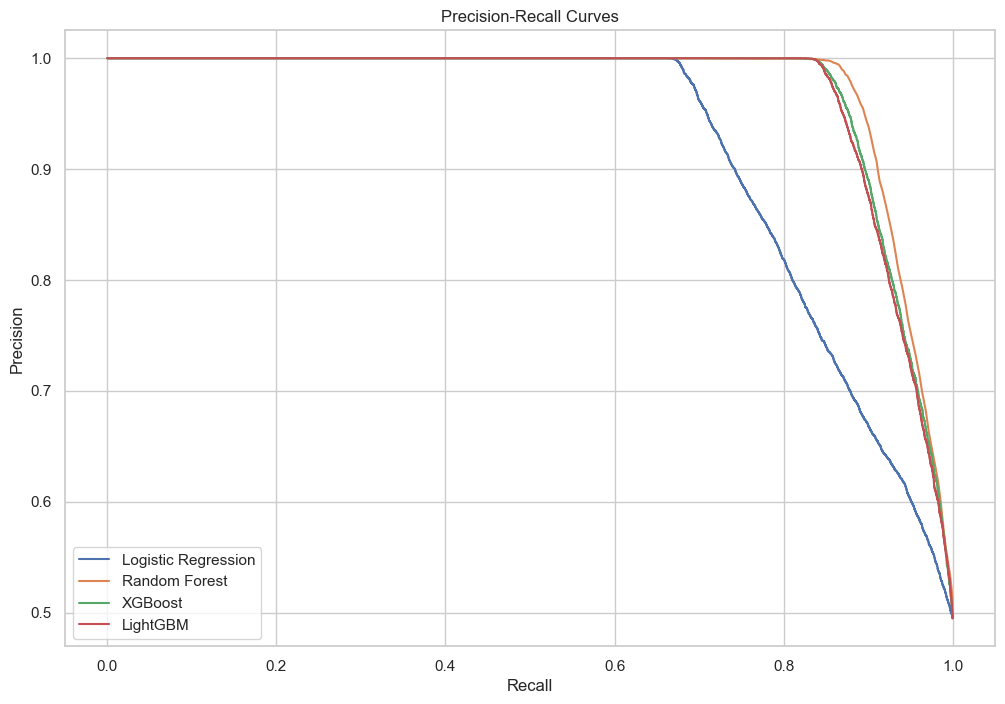

In [11]:
# Plot ROC Curves for all models
plt.figure(figsize=(12, 8))
for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Plot Precision-Recall Curves for all models
plt.figure(figsize=(12, 8))
for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    plt.plot(recall, precision, label=f'{model_name}')
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()